# MOMARL Results Visualization

Visualize Multi-Objective Multi-Agent RL training results from WandB logs.

**Features:** Pareto front, hypervolume comparison, hypervolume learning curve

## 1. Configuration

In [92]:
from pathlib import Path

# Paths
RESULTS_DIR = Path("../momarl_results")
OUTPUT_DIR = Path("./figures")

# Hypervolume reference point (origin for maximization)
HYPERVOLUME_REF_POINT = [0.0, 0.0]

# Objective names for axis labels
OBJECTIVE_NAMES = ["inverse_global_temperature", "global_economic_output"]

# Plot settings
FIGURE_DPI = 150
SAVE_FIGURES = True

# Filter runs with returns below these thresholds (set to None to disable)
MIN_RETURN_OBJ_0 = 10.0
MIN_RETURN_OBJ_1 = 10.0

# WandB settings
USE_WANDB_API = True
WANDB_PROJECT = "harl_justice_momarl"
WANDB_ENTITY = "olaandrasz-tu-delft"

## 2. Imports

In [93]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

# Hypervolume (DEAP)
try:
    from deap.tools._hypervolume import hv
    HV_AVAILABLE = True
except ImportError:
    HV_AVAILABLE = False
    warnings.warn("DEAP not installed - hypervolume unavailable")

# WandB
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    warnings.warn("wandb not installed")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"HV: {HV_AVAILABLE}, WandB: {WANDB_AVAILABLE}")

if WANDB_AVAILABLE and USE_WANDB_API:
    try:
        wandb.login()
        print("WandB login successful")
    except Exception as e:
        print(f"WandB login failed: {e}")

HV: True, WandB: True
WandB login successful


## 3. Data Loading

In [94]:
@dataclass
class RunData:
    """Container for a single WandB run."""
    run_id: str
    algorithm: str
    weights: List[float]
    weight_idx: int
    return_obj_0: float
    return_obj_1: float
    vector_return: List[float]
    timestamp: str
    total_steps: int


def load_json(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)


def extract_algorithm(metadata: Dict) -> str:
    """Extract algorithm name from wandb metadata args."""
    args = metadata.get("args", [])
    for i, arg in enumerate(args):
        if arg == "--algo" and i + 1 < len(args):
            return args[i + 1].upper()
    return "UNKNOWN"


def parse_run(run_dir: Path) -> Optional[RunData]:
    """Parse a single WandB run directory."""
    metadata = load_json(run_dir / "files" / "wandb-metadata.json")
    summary = load_json(run_dir / "files" / "wandb-summary.json")
    
    if metadata is None or summary is None:
        return None
    
    run_name = run_dir.name
    parts = run_name.split("-")
    
    return RunData(
        run_id=parts[-1] if len(parts) > 1 else run_name,
        algorithm=extract_algorithm(metadata),
        weights=summary.get("weights", [0.5, 0.5]),
        weight_idx=summary.get("weight_idx", -1),
        return_obj_0=summary.get("return_obj_0") or summary.get("final/return_obj_0") or 0.0,
        return_obj_1=summary.get("return_obj_1") or summary.get("final/return_obj_1") or 0.0,
        vector_return=summary.get("vector_return") or summary.get("final/vector_return") or [0.0, 0.0],
        timestamp=parts[1] if len(parts) > 1 else "",
        total_steps=summary.get("total_num_steps", 0)
    )


def load_all_runs(results_dir: Path) -> List[RunData]:
    """Load all WandB runs from a directory."""
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith("run-")])
    runs = [parse_run(d) for d in run_dirs]
    return [r for r in runs if r is not None]


def runs_to_dataframe(runs: List[RunData]) -> pd.DataFrame:
    """Convert RunData list to DataFrame."""
    return pd.DataFrame([{
        "run_id": r.run_id,
        "algorithm": r.algorithm,
        "weight_0": r.weights[0] if r.weights else 0.0,
        "weight_1": r.weights[1] if len(r.weights) > 1 else 0.0,
        "weight_idx": r.weight_idx,
        "return_obj_0": r.return_obj_0,
        "return_obj_1": r.return_obj_1,
        "timestamp": r.timestamp,
        "total_steps": r.total_steps,
    } for r in runs])

## 4. Load Runs

In [95]:
runs = load_all_runs(RESULTS_DIR)
df = runs_to_dataframe(runs)

# Filter failed runs
original_count = len(df)
if MIN_RETURN_OBJ_0:
    df = df[df["return_obj_0"] >= MIN_RETURN_OBJ_0]
if MIN_RETURN_OBJ_1:
    df = df[df["return_obj_1"] >= MIN_RETURN_OBJ_1]

if len(df) < original_count:
    print(f"Filtered {original_count - len(df)} runs below threshold")

print(f"Loaded {len(df)} runs from {RESULTS_DIR}")
print(df["algorithm"].value_counts())
df.head(10)

Filtered 1 runs below threshold
Loaded 16 runs from ../momarl_results
algorithm
HAPPO    10
MAPPO     6
Name: count, dtype: int64


,run_id,algorithm,weight_0,weight_1,weight_idx,return_obj_0,return_obj_1,timestamp,total_steps
0,m2pbn0xc,MAPPO,0.000000,1.000000,0,87.228790,361.401454,20260220_190746,2850000
1,pqshfuw5,HAPPO,0.000000,1.000000,0,80.247867,352.675098,20260220_190746,2850000
2,apr1gmys,HAPPO,0.110379,0.889621,1,95.415718,372.385191,20260220_205900,2850000
3,7ydgsdqb,MAPPO,0.110379,0.889621,1,96.937792,353.049379,20260220_222746,2850000
4,zchi01il,HAPPO,0.221658,0.778342,2,117.183920,371.083932,20260220_224209,2850000
5,qwj33hmf,HAPPO,0.332974,0.667026,3,135.291358,388.125300,20260221_002220,2850000
6,dtrcllil,MAPPO,0.221658,0.778342,2,115.590088,353.163064,20260221_013651,2850000
7,10dbsqyw,HAPPO,0.444312,0.555688,4,141.149194,386.272495,20260221_020619,2850000
8,4lfyphl0,HAPPO,0.555749,0.444251,5,151.048433,368.144752,20260221_034855,2850000
9,fsbfysgh,MAPPO,0.332974,0.667026,3,128.686846,352.502255,20260221_044702,2850000


## 5. Pareto Front

In [96]:
COLORS = {"HAPPO": "#1f77b4", "MAPPO": "#ff7f0e", "UNKNOWN": "#7f7f7f"}
MARKERS = {"HAPPO": "o", "MAPPO": "s", "UNKNOWN": "^"}


def is_pareto_efficient(points: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points (maximization)."""
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                is_efficient[i] = False
                break
    return is_efficient


def plot_pareto_front(df: pd.DataFrame, show_weights: bool = True) -> plt.Figure:
    """Plot Pareto front comparison between algorithms."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for algo in df["algorithm"].unique():
        algo_df = df[df["algorithm"] == algo]
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color, marker = COLORS.get(algo, "#333"), MARKERS.get(algo, "x")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        
        # Non-Pareto (faded)
        non_pareto = ~pareto_mask
        if non_pareto.any():
            ax.scatter(points[non_pareto, 0], points[non_pareto, 1],
                      c=color, s=80, marker=marker, alpha=0.4,
                      edgecolors='gray', linewidths=0.5, label=f"{algo} (dominated)")
        
        # Pareto (highlighted)
        if pareto_mask.any():
            ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='black', linewidths=1.5, label=f"{algo} (Pareto)")
        
        # Weight annotations
        if show_weights:
            for _, row in algo_df.iterrows():
                ax.annotate(f"({row['weight_0']:.2f}, {row['weight_1']:.2f})",
                           (row["return_obj_0"], row["return_obj_1"]),
                           textcoords="offset points", xytext=(5, 5 if algo == "HAPPO" else -12),
                           fontsize=7, color=color, alpha=0.8)
    
    ax.set_xlabel(OBJECTIVE_NAMES[0].replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(OBJECTIVE_NAMES[1].replace('_', ' ').title(), fontsize=12)
    ax.set_title("Pareto Front: HAPPO vs MAPPO", fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

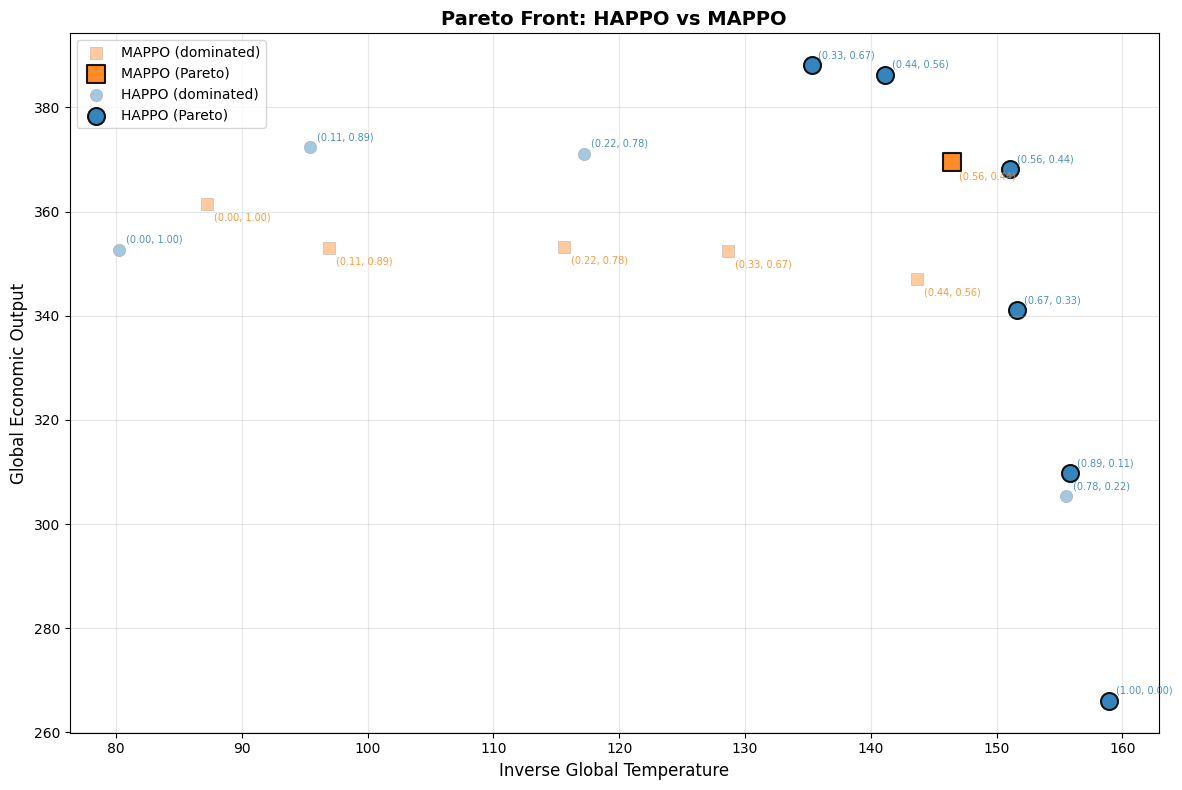

In [97]:
fig_pareto = plot_pareto_front(df)
if SAVE_FIGURES:
    fig_pareto.savefig(OUTPUT_DIR / "pareto_front.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 6. Hypervolume Over Time

In [ ]:
def compute_hypervolume(points: np.ndarray, ref_point: List[float]) -> float:
    """Compute hypervolume for points (maximization). DEAP assumes minimization, so we negate."""
    if not HV_AVAILABLE or len(points) == 0:
        return 0.0
    
    ref = np.array(ref_point)
    valid_mask = np.all(points > ref, axis=1)
    if not valid_mask.any():
        return 0.0
    
    # Negate for DEAP (minimization)
    return hv.hypervolume((-points[valid_mask]).tolist(), (-ref).tolist())


def fetch_training_history_from_wandb(runs_df, entity: str, project: str) -> Dict[str, pd.DataFrame]:
    """Fetch training history for all runs from WandB API.
    Returns histories dict with algorithm info embedded in each DataFrame."""
    api = wandb.Api()
    
    histories = {}
    
    for run_id, algorithm in zip(runs_df["run_id"], runs_df["algorithm"]):
        online_data = api.run(f"{entity}/{project}/{run_id}")
        #print(f"Fetching run {run_id}")
        if "summary" in online_data.name.lower():
            continue
        
        zero_df = online_data.history(keys=["0"])
        one_df = online_data.history(keys=["1"])
        steps_df = online_data.history(keys=["total_num_steps"])
        history_df = pd.DataFrame({
            "run_id": run_id,
            "algorithm": algorithm,
            "total_num_steps": steps_df["total_num_steps"],
            "0": zero_df["0"],
            "1": one_df["1"]
        })
        
        histories[run_id] = history_df
    return histories


def compute_hypervolume_over_time(histories: Dict[str, pd.DataFrame],
                                   ref_point: List[float], num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """Compute hypervolume at each time bin for each algorithm.
    
    At each timestep:
    1. Collects ALL points logged up to that timestep (across all runs)
    2. Filters to Pareto-optimal points only
    3. Computes hypervolume on the Pareto front
    
    This shows learning: as training progresses, more/better solutions are discovered,
    expanding the Pareto front and increasing hypervolume.
    """
    if not HV_AVAILABLE:
        return {}
    
    # Group histories by algorithm (extracted from DataFrame)
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        algo = hist["algorithm"].iloc[0] if len(hist) > 0 else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    results = {}
    for algo, hist_list in algo_histories.items():
        # Collect ALL data points: (steps, obj_0, obj_1) from all runs
        all_data = []
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            for _, row in valid_rows.iterrows():
                all_data.append((row["total_num_steps"], row["0"], row["1"]))
        
        if not all_data:
            continue
        
        all_data.sort(key=lambda x: x[0])
        max_steps = int(all_data[-1][0])
        
        # Compute HV at each timestep
        hv_values, step_centers = [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            # Collect ALL points up to this threshold
            points = np.array([[d[1], d[2]] for d in all_data if d[0] <= threshold])
            
            if len(points) > 0:
                try:
                    # Filter to Pareto-optimal points only
                    pareto_mask = is_pareto_efficient(points)
                    pareto_points = points[pareto_mask]
                    # Compute hypervolume on Pareto front
                    hv_val = compute_hypervolume(pareto_points, ref_point)
                    hv_values.append(hv_val)
                    step_centers.append(threshold)
                except Exception:
                    pass
        
        if hv_values:
            results[algo] = (np.array(step_centers), np.array(hv_values))
    
    return results


def plot_hypervolume_over_time(hv_over_time: Dict[str, Tuple[np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot hypervolume learning curves."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, (steps, hv_vals) in hv_over_time.items():
        ax.plot(steps, hv_vals, color=COLORS.get(algo, "#333"), linewidth=2, marker='o', markersize=3, label=algo)
        ax.annotate(f'{hv_vals[-1]:.0f}', xy=(steps[-1], hv_vals[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=COLORS.get(algo, "#333"))
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Hypervolume")
    ax.set_title(f"Hypervolume Over Training (ref={HYPERVOLUME_REF_POINT})", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

In [109]:
if WANDB_AVAILABLE and USE_WANDB_API and HV_AVAILABLE:
    print("Fetching from WandB API...")
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)
    
    # Extract algorithms from histories
    algos_found = {hist["algorithm"].iloc[0] for hist in histories.values() if len(hist) > 0}
    print(f"\nLoaded {len(histories)} runs, algorithms: {algos_found}")

Fetching from WandB API...

Loaded 16 runs, algorithms: {'MAPPO', 'HAPPO'}


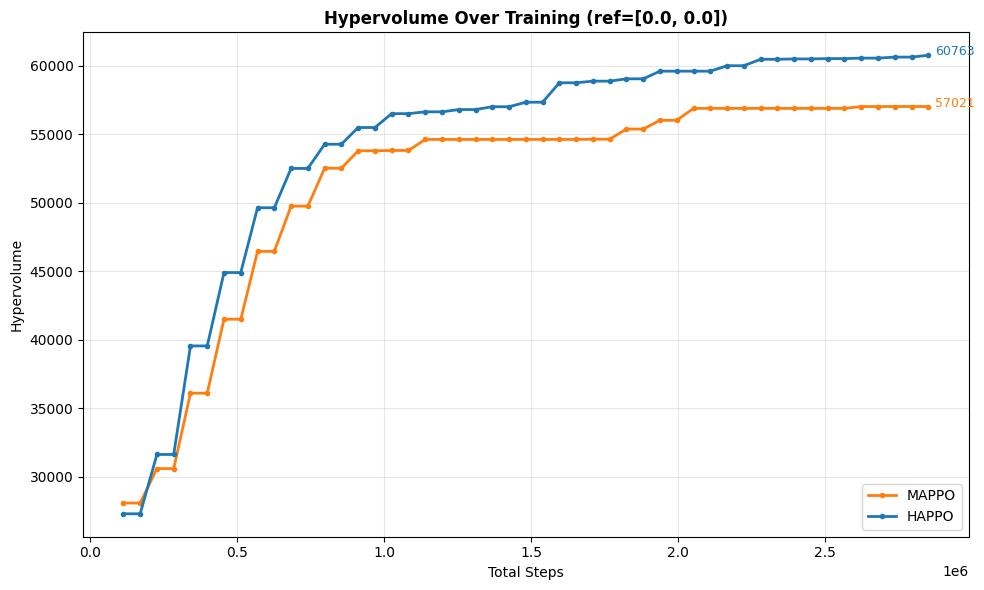

In [113]:
hv_over_time = compute_hypervolume_over_time(histories, HYPERVOLUME_REF_POINT)

if hv_over_time:
    fig_hv_time = plot_hypervolume_over_time(hv_over_time)
    if SAVE_FIGURES:
        fig_hv_time.savefig(OUTPUT_DIR / "hypervolume_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for HV over time")


## 7. Summary

In [100]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

for algo in df["algorithm"].unique():
    algo_df = df[df["algorithm"] == algo]
    points = algo_df[["return_obj_0", "return_obj_1"]].values
    pareto_count = is_pareto_efficient(points).sum()
    
    print(f"\n{algo} ({len(algo_df)} runs, {pareto_count} Pareto):")
    for i, name in enumerate(OBJECTIVE_NAMES):
        col = f"return_obj_{i}"
        print(f"  {name}: {algo_df[col].mean():.2f} ± {algo_df[col].std():.2f} [{algo_df[col].min():.2f}, {algo_df[col].max():.2f}]")

print("\n" + "=" * 60)
df.sort_values(["algorithm", "weight_idx"])

SUMMARY STATISTICS

MAPPO (6 runs, 1 Pareto):
  inverse_global_temperature: 119.77 ± 24.34 [87.23, 146.50]
  global_economic_output: 356.10 ± 7.98 [347.06, 369.44]

HAPPO (10 runs, 6 Pareto):
  inverse_global_temperature: 134.23 ± 27.65 [80.25, 158.96]
  global_economic_output: 346.09 ± 40.33 [266.03, 388.13]



,run_id,algorithm,weight_0,weight_1,weight_idx,return_obj_0,return_obj_1,timestamp,total_steps
1,pqshfuw5,HAPPO,0.000000,1.000000,0,80.247867,352.675098,20260220_190746,2850000
2,apr1gmys,HAPPO,0.110379,0.889621,1,95.415718,372.385191,20260220_205900,2850000
4,zchi01il,HAPPO,0.221658,0.778342,2,117.183920,371.083932,20260220_224209,2850000
5,qwj33hmf,HAPPO,0.332974,0.667026,3,135.291358,388.125300,20260221_002220,2850000
7,10dbsqyw,HAPPO,0.444312,0.555688,4,141.149194,386.272495,20260221_020619,2850000
8,4lfyphl0,HAPPO,0.555749,0.444251,5,151.048433,368.144752,20260221_034855,2850000
10,600wqd8h,HAPPO,0.667005,0.332995,6,151.633140,341.041547,20260221_053029,2850000
11,aiuvpzhc,HAPPO,0.778365,0.221635,7,155.536719,305.357886,20260221_071020,2850000
13,64nr2kbo,HAPPO,0.889606,0.110394,8,155.876577,309.772471,20260221_084839,2850000
14,pevi62p0,HAPPO,1.000000,0.000000,9,158.955766,266.026881,20260221_102858,2850000
